In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy import stats
from itertools import combinations
from rdkit import Chem
from rdkit.Chem import Lipinski, Descriptors

In [2]:
# ── rcParams (точно як у вашому стилі) ────────────────────────────────────────
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = [
    'Times New Roman', 'Liberation Serif',
    'DejaVu Serif', 'Bitstream Vera Serif', 'serif'
]
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ── Шляхи до файлів ───────────────────────────────────────────────────────────
BASE = "../data/link_invent_outputs"

SCORED = {
    "Raw Prior":     f"{BASE}/scored_sampling_test_raw_prior_full.csv",
    "PROTAC Active": f"{BASE}/scored_sampling_test_protac_active_full.csv",
    "Optimised":     f"{BASE}/scored_sampling_test_protac_optimized_full.csv",
}
ADMET = {
    "Raw Prior":     f"{BASE}/admet_test_raw_prior.csv",
    "PROTAC Active": f"{BASE}/admet_test_protac_active_full.csv",
    "Optimised":     f"{BASE}/admet_test_protac_optimized_full.csv",
}

GEN_ORDER = ["Raw Prior", "PROTAC Active", "Optimised"]

# Відображувані назви на графіках (внутрішні ключі не змінюються)
GEN_LABELS = {
    "Raw Prior":     "Апріорна вибірка",
    "PROTAC Active": "RL: Біологічна активність",
    "Optimised":     "RL: Активність + TPSA",
}
PALETTE = {
    "Raw Prior":     "#9F9F9F",  
    "PROTAC Active": "#C1392B",
    "Optimised":     "#2471A3", 
}

In [4]:
# ── Аналіз лінкера ────────────────────────────────────────────────────────────
def analyze_linker(linker_smi):
    if pd.isna(linker_smi):
        return None, None, None
    mol = Chem.MolFromSmiles(linker_smi)
    if not mol:
        return None, None, None
    length    = mol.GetNumHeavyAtoms()
    f_csp3    = Lipinski.FractionCSP3(mol)
    rot_bonds = Descriptors.NumRotatableBonds(mol)
    return length, f_csp3, rot_bonds

In [5]:
# ── Завантаження даних ────────────────────────────────────────────────────────
scored_dfs, admet_dfs = {}, {}
for name in GEN_ORDER:
    s = pd.read_csv(SCORED[name]).dropna(subset=["SMILES", "Active_Probability"])
    s["Generation"] = name
    s[["Linker_Length", "Linker_fCsp3", "Linker_RotBonds"]] = s["Linker"].apply(
        lambda x: pd.Series(analyze_linker(x))
    )
    scored_dfs[name] = s

    a = pd.read_csv(ADMET[name]).dropna(subset=["SMILES"])
    a["Generation"] = name
    admet_dfs[name] = a

df_scored = pd.concat(scored_dfs.values(), ignore_index=True)
df_admet  = pd.concat(admet_dfs.values(),  ignore_index=True)

# Категоріальний порядок для seaborn
df_scored["Generation"] = pd.Categorical(df_scored["Generation"], categories=GEN_ORDER, ordered=True)
df_admet["Generation"]  = pd.Categorical(df_admet["Generation"],  categories=GEN_ORDER, ordered=True)

METRICS = {
    "Active_Probability": {
        "df": df_scored,
        "label": "Ймовірність активності",
        "ylabel": "Ймовірність активності",
    },
    "tpsa": {
        "df": df_admet,
        "label": "Полярна площа поверхні (TPSA, Å²)",
        "ylabel": "TPSA (Å²)",
    },
    "Caco2_Wang": {
        "df": df_admet,
        "label": "Клітинна проникність (Caco-2, logPapp)",
        "ylabel": "Caco-2 (logPapp)",
    },
    "Linker_fCsp3": {
        "df": df_scored,
        "label": "Частка sp³-вуглеців лінкера (fCsp3)",
        "ylabel": "fCsp3 лінкера",
    },
}

In [6]:
# ── Статистика ────────────────────────────────────────────────────────────────
def kruskal_pairwise(groups: dict, alpha: float = 0.05):
    arrays   = [g.dropna().values for g in groups.values()]
    kw_stat, kw_p = stats.kruskal(*arrays)
    pair_keys = list(combinations(groups.keys(), 2))
    raw_ps    = [
        stats.mannwhitneyu(groups[a].dropna(), groups[b].dropna(),
                           alternative="two-sided")[1]
        for a, b in pair_keys
    ]
    bonf = [min(p * len(pair_keys), 1.0) for p in raw_ps]

    def stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

    pairs_out = [
        {"pair": pk, "p_raw": pr, "p_bonf": pb, "stars": stars(pb)}
        for pk, pr, pb in zip(pair_keys, raw_ps, bonf)
    ]
    return {"statistic": kw_stat, "p": kw_p, "significant": kw_p < alpha}, pairs_out

stat_results = {}
for col, cfg in METRICS.items():
    groups = {
        g: cfg["df"].loc[cfg["df"]["Generation"] == g, col]
        for g in GEN_ORDER
    }
    kw, pairs = kruskal_pairwise(groups)
    stat_results[col] = {"kw": kw, "pairs": pairs, "groups": groups}

    print(f"\n{'═'*55}")
    print(f"  {cfg['label'].replace(chr(10), ' ')}")
    print(f"  Kruskal–Wallis  H={kw['statistic']:.2f}, p={kw['p']:.2e}"
          f"  {'✓ sig.' if kw['significant'] else '✗ not sig.'}")
    print("  Pairwise Mann–Whitney U  (Bonferroni-corrected):")
    for r in pairs:
        a, b = r["pair"]
        print(f"    {a} vs {b}: p_raw={r['p_raw']:.2e}, "
              f"p_bonf={r['p_bonf']:.2e}  {r['stars']}")

# ── Дужка значущості ──────────────────────────────────────────────────────────
def draw_bracket(ax, x1, x2, y, h, label, fontsize=14):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            lw=1.2, color="black")
    ax.text((x1 + x2) / 2, y + h * 1.05, label,
            ha="center", va="bottom", fontsize=fontsize,
            fontfamily="serif")


═══════════════════════════════════════════════════════
  Ймовірність активності
  Kruskal–Wallis  H=872.66, p=3.19e-190  ✓ sig.
  Pairwise Mann–Whitney U  (Bonferroni-corrected):
    Raw Prior vs PROTAC Active: p_raw=9.09e-147, p_bonf=2.73e-146  ***
    Raw Prior vs Optimised: p_raw=2.22e-158, p_bonf=6.65e-158  ***
    PROTAC Active vs Optimised: p_raw=3.54e-01, p_bonf=1.00e+00  ns

═══════════════════════════════════════════════════════
  Полярна площа поверхні (TPSA, Å²)
  Kruskal–Wallis  H=572.52, p=4.78e-125  ✓ sig.
  Pairwise Mann–Whitney U  (Bonferroni-corrected):
    Raw Prior vs PROTAC Active: p_raw=1.11e-23, p_bonf=3.33e-23  ***
    Raw Prior vs Optimised: p_raw=5.06e-116, p_bonf=1.52e-115  ***
    PROTAC Active vs Optimised: p_raw=1.25e-54, p_bonf=3.74e-54  ***

═══════════════════════════════════════════════════════
  Клітинна проникність (Caco-2, logPapp)
  Kruskal–Wallis  H=319.20, p=4.86e-70  ✓ sig.
  Pairwise Mann–Whitney U  (Bonferroni-corrected):
    Raw Prior vs PRO

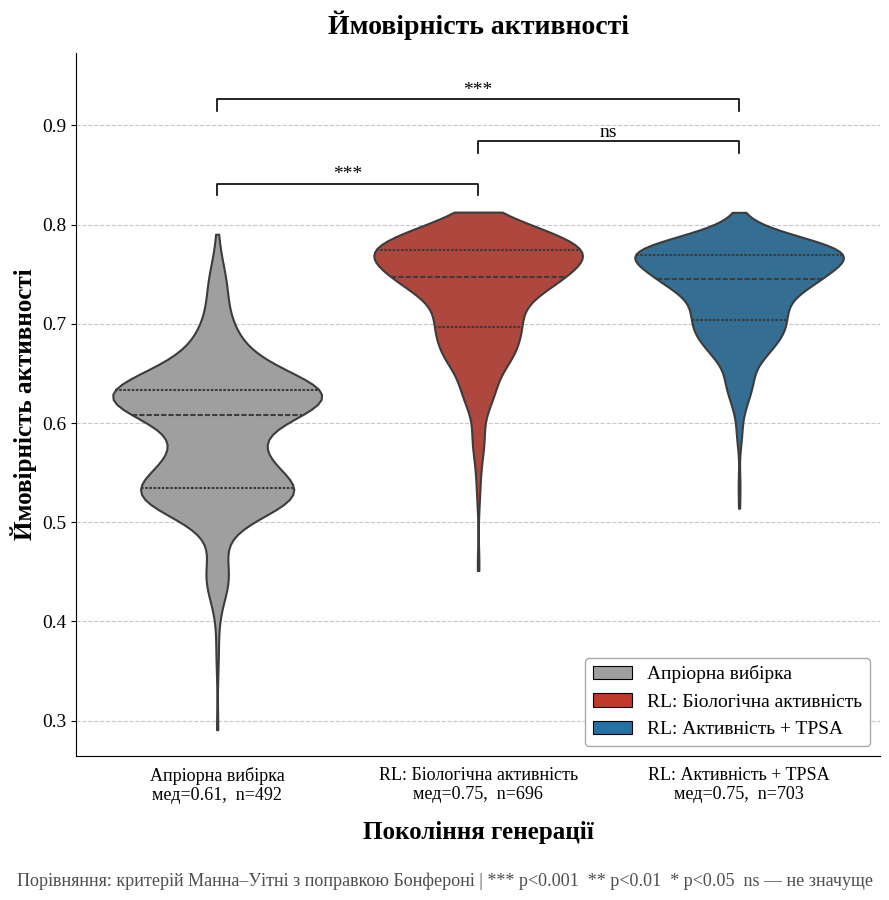

Збережено: violin_active_probability.png


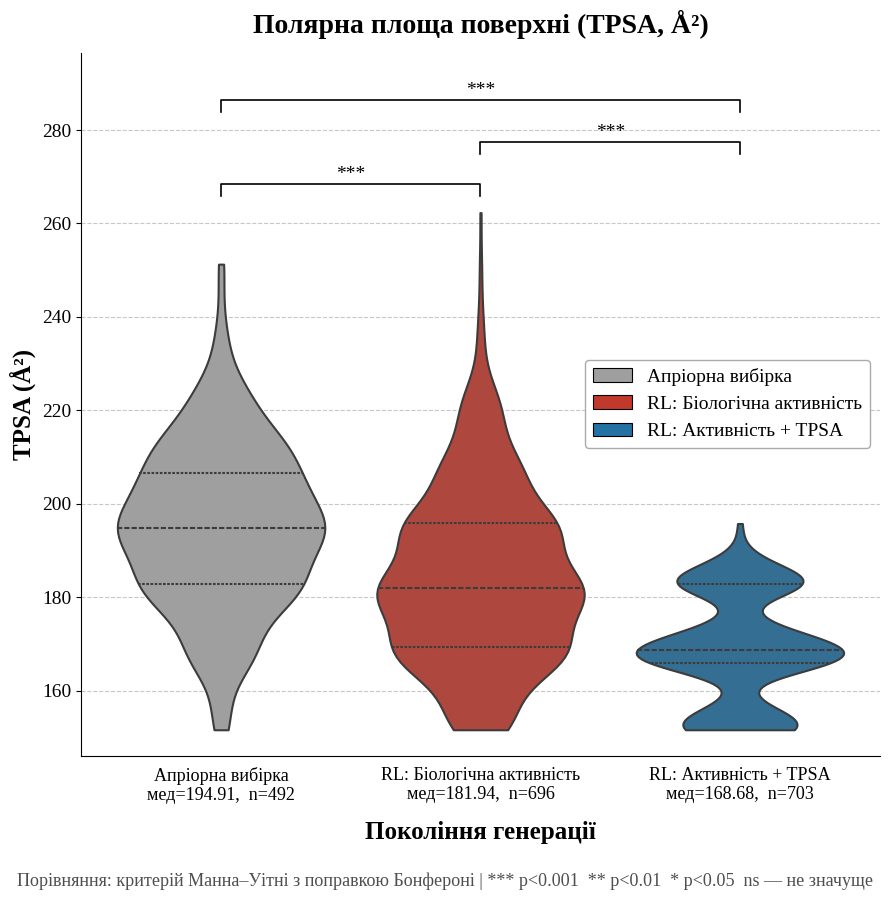

Збережено: violin_tpsa.png


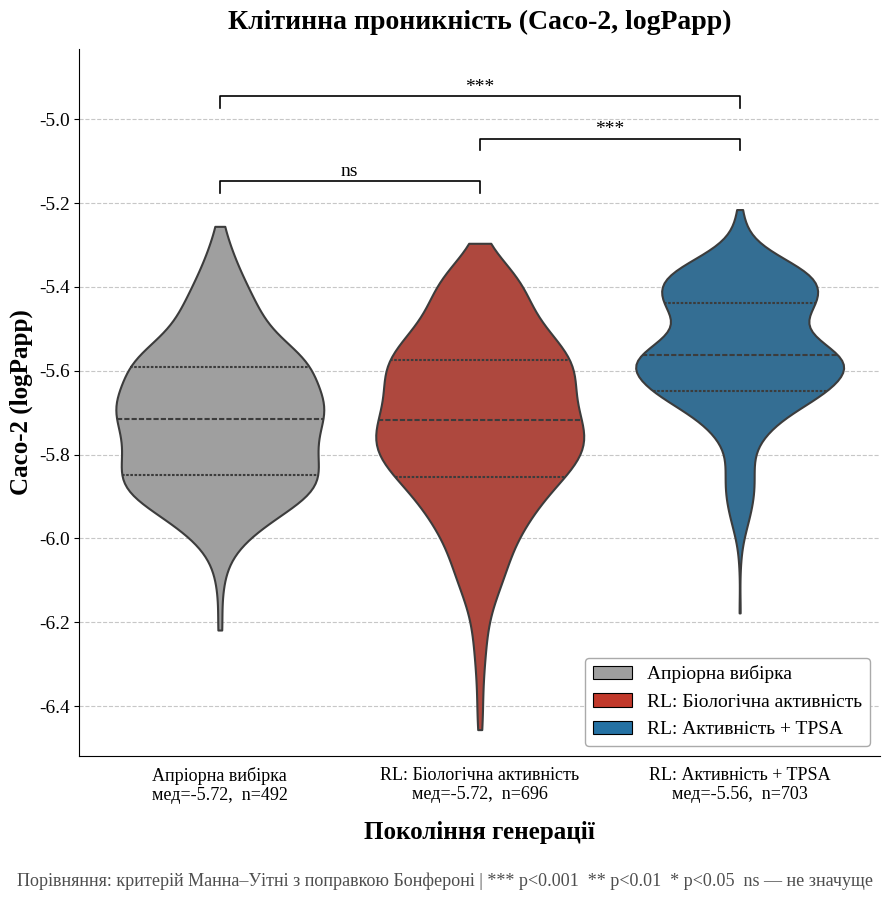

Збережено: violin_caco2_wang.png


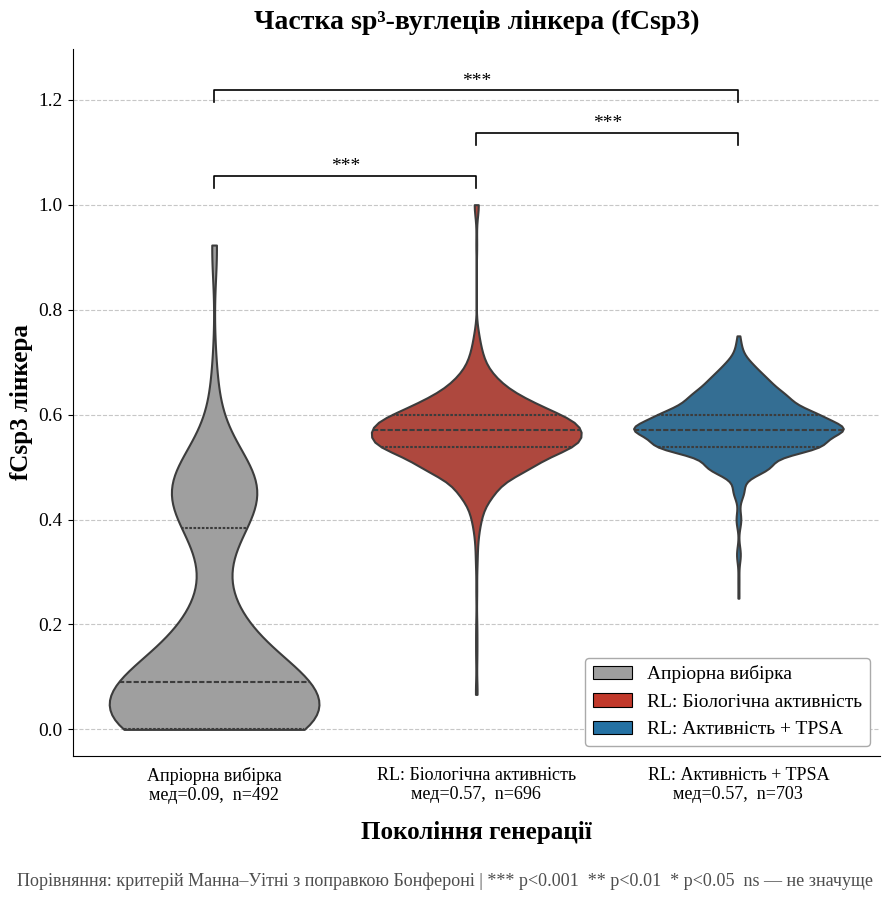

Збережено: violin_linker_fcsp3.png


In [7]:
# ── Константи для дужок (спільні) ────────────────────────────────────────────
PAIR_XPOS = {
    ("Raw Prior", "PROTAC Active"): (0, 1),
    ("PROTAC Active", "Optimised"): (1, 2),
    ("Raw Prior", "Optimised"):     (0, 2),
}
BRACKET_LEVEL = {
    ("Raw Prior", "PROTAC Active"): 0,
    ("PROTAC Active", "Optimised"): 1,
    ("Raw Prior", "Optimised"):     2,
}

# ── Індивідуальні налаштування для кожного графіка ───────────────────────────
PLOT_CFG = {
    "Active_Probability": {
        # Легенда: верхній лівий кут — там є вільний простір (Raw Prior йде вниз)
        "legend_loc":  "lower right",
        "legend_bbox": None,
        # Відступ зверху для дужок (у частках від діапазону даних)
        "top_pad":  0.28,
        "filename": "violin_active_probability.png",
    },
    "tpsa": {
        # Легенда: верхній правий — Optimised вузький внизу, Raw/PROTAC широкі вгорі,
        # тому єдиний вільний кут — верхній правий поза тілами скрипок
        "legend_loc":  "center right",
        "legend_bbox": None,
        "top_pad":  0.30,
        "filename": "violin_tpsa.png",
    },
    "Caco2_Wang": {
        "legend_loc":  "lower right",
        "legend_bbox": None,
        "top_pad":  0.30,
        "filename": "violin_caco2_wang.png",
    },
    "Linker_fCsp3": {
        # Raw Prior розтягнутий вгору до ~0.93, решта компактні.
        # Легенда в нижньому правому — там є чистий простір між Optimised та краєм
        "legend_loc":  "lower right",
        "legend_bbox": None,
        "top_pad":  0.18,
        "filename": "violin_linker_fcsp3.png",
    },
}

# ── Функція побудови одного графіка ───────────────────────────────────────────
def plot_single_violin(col, metric_cfg, plot_cfg, stat_res):
    df_plot  = metric_cfg["df"].copy()
    n_by_gen = df_plot.groupby("Generation", observed=True)[col].count()

    fig, ax = plt.subplots(figsize=(9, 9))

    # ── Violin ────────────────────────────────────────────────────────────────
    sns.violinplot(
        x="Generation", y=col,
        data=df_plot, order=GEN_ORDER,
        palette=PALETTE, hue="Generation",
        legend=False, cut=0,
        inner="quartile", linewidth=1.5,
        density_norm="width", ax=ax,
    )

    # ── Підписи тіків: назва + med + n (уникаємо накладань з xlabel) ─────────
    tick_labels = []
    for gen in GEN_ORDER:
        arr = df_plot.loc[df_plot["Generation"] == gen, col].dropna()
        med = np.median(arr)
        n   = n_by_gen[gen]
        fmt = f".2f" if col != "TPSA" else f".1f"
        tick_labels.append(f"{GEN_LABELS[gen]}\nмед={med:{fmt}},  n={n:,}")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(tick_labels, fontsize=13, fontfamily="serif")
    ax.tick_params(axis="x", which="both", length=0, pad=8)

    # ── Осі та сітка ──────────────────────────────────────────────────────────
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(metric_cfg["label"], fontsize=20, fontweight="bold", pad=14)
    ax.set_xlabel("Покоління генерації", fontsize=18, fontweight="bold", labelpad=12)
    ax.set_ylabel(metric_cfg["ylabel"], fontsize=18, fontweight="bold")
    ax.tick_params(axis="y", labelsize=14)

    # ── Дужки значущості ─────────────────────────────────────────────────────
    all_vals = df_plot[col].dropna()
    data_max = np.nanmax(all_vals)
    data_rng = data_max - np.nanmin(all_vals)
    step     = data_rng * 0.065

    # Верхня межа осі з місцем для всіх трьох рівнів дужок
    y_bracket_base = data_max + step * 0.5
    y_axis_top     = y_bracket_base + step * (0.5 + 2 * 1.25) + step * 0.8
    ax.set_ylim(top=y_axis_top + data_rng * plot_cfg["top_pad"] * 0.1)

    for pr in stat_res["pairs"]:
        a, b    = pr["pair"]
        x1, x2  = PAIR_XPOS[(a, b)]
        level   = BRACKET_LEVEL[(a, b)]
        y_br    = y_bracket_base + step * level * 1.25
        draw_bracket(ax, x1, x2, y_br, step * 0.35, pr["stars"], fontsize=14)

    # ── Легенда ───────────────────────────────────────────────────────────────
    legend_patches = [
        patches.Patch(facecolor=PALETTE[g], edgecolor="black",
                      linewidth=0.8, label=GEN_LABELS[g])
        for g in GEN_ORDER
    ]
    legend_kw = dict(
        handles=legend_patches,
        loc=plot_cfg["legend_loc"],
        prop={"size": 14, "family": "serif"},
        framealpha=1.0, edgecolor="#aaaaaa",
    )
    if plot_cfg["legend_bbox"]:
        legend_kw["bbox_to_anchor"] = plot_cfg["legend_bbox"]
    ax.legend(**legend_kw)

    # ── Підпис статистики ─────────────────────────────────────────────────────
    fig.text(
        0.5, 0.01,
        "Порівняння: критерій Манна–Уітні з поправкою Бонфероні | "
        "*** p<0.001  ** p<0.01  * p<0.05  ns — не значуще",
        ha="center", fontsize=13, fontfamily="serif", color="#4E4E4E",
    )

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(plot_cfg["filename"], dpi=400, bbox_inches="tight")
    plt.show()
    print(f"Збережено: {plot_cfg['filename']}")

# ── Генерація графіків ────────────────────────────────────────────────────────
for col, metric_cfg in METRICS.items():
    plot_single_violin(col, metric_cfg, PLOT_CFG[col], stat_results[col])

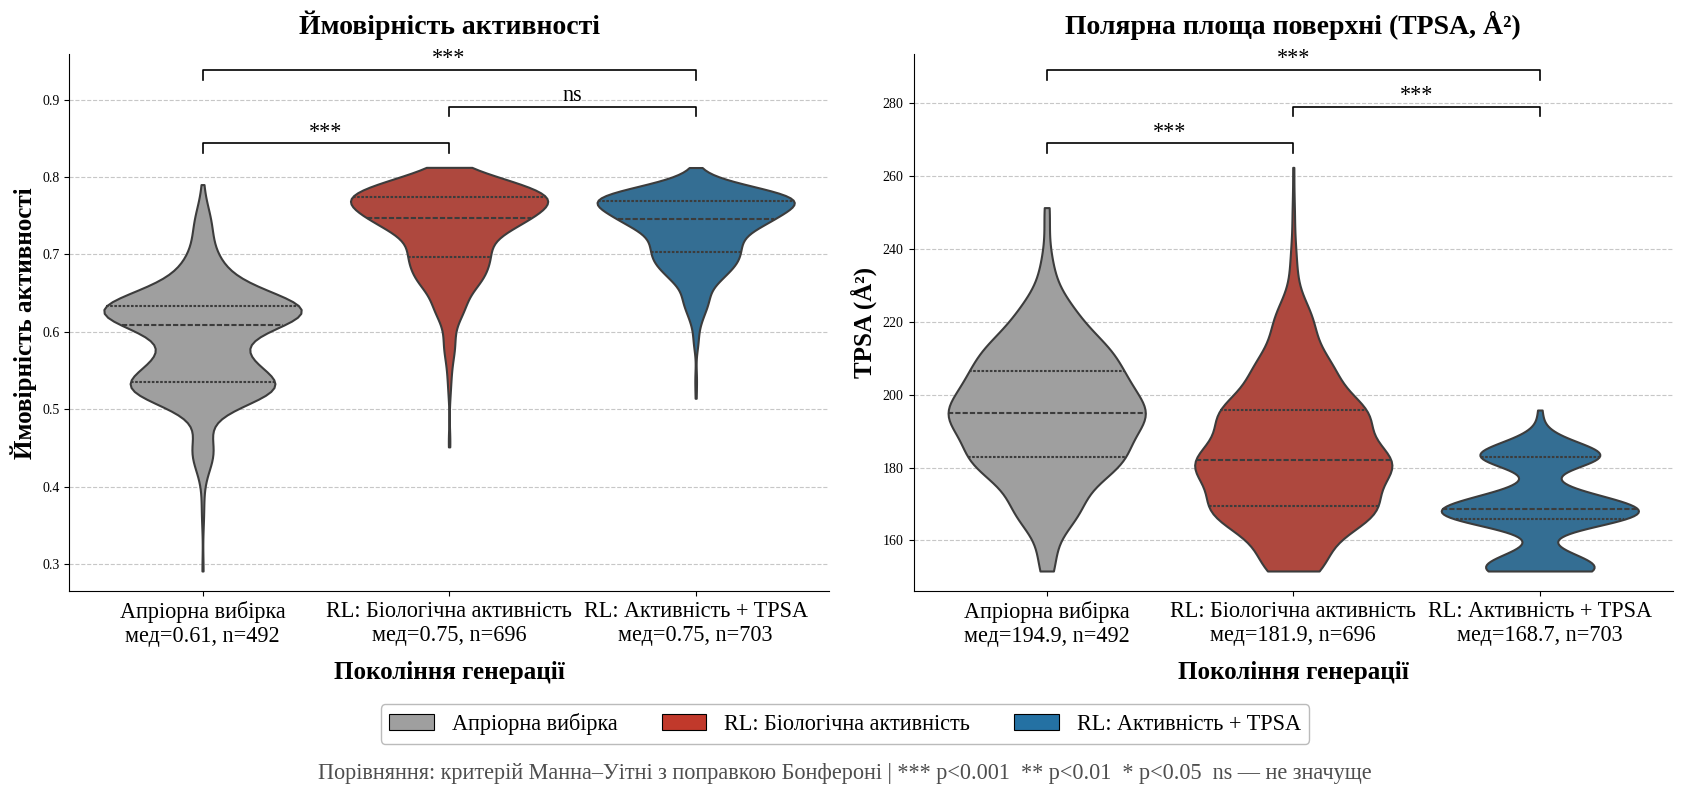

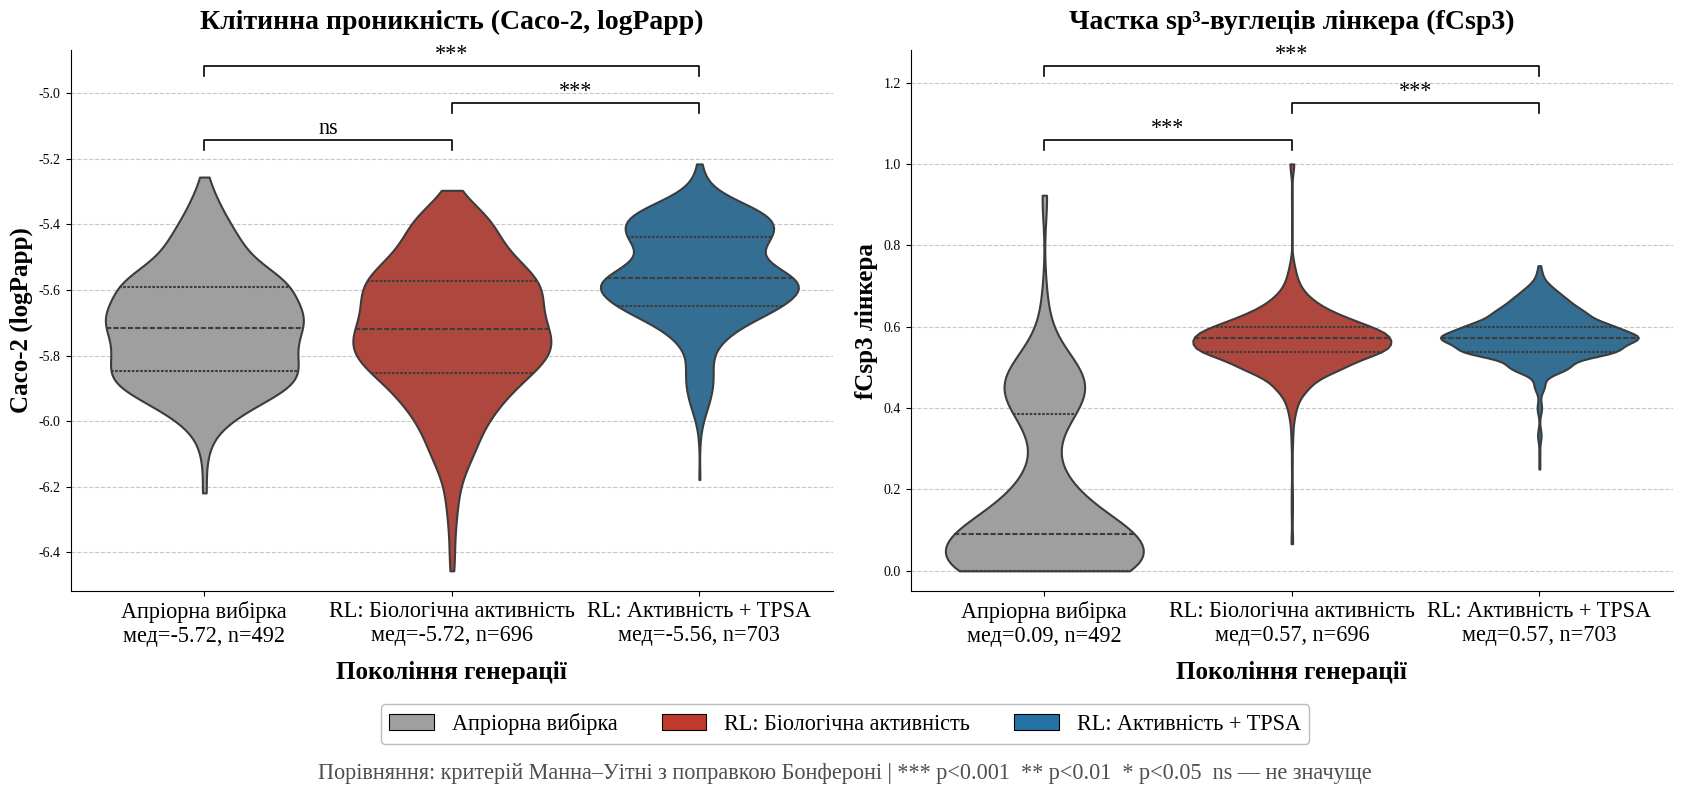

In [22]:
# ── Налаштування груп ────────────────────────────────────────────────────────
GROUPS = [
    {
        "cols": ["Active_Probability", "tpsa"],
        "filename": "combined_activity_tpsa.png"
    },
    {
        "cols": ["Caco2_Wang", "Linker_fCsp3"],
        "filename": "combined_caco2_fcsp3.png"
    }
]

# ── Функція побудови комбінованого графіка (1 рядок, 2 колонки) ───────────────
def plot_combined_violins(cols, filename, METRICS, PLOT_CFG, stat_results):
    fig, axes = plt.subplots(1, 2, figsize=(17, 8)) # Трохи збільшив висоту для місця знизу
    
    legend_patches = [
        patches.Patch(facecolor=PALETTE[g], edgecolor="black", linewidth=0.8, label=GEN_LABELS[g])
        for g in GEN_ORDER
    ]

    for idx, col in enumerate(cols):
        ax = axes[idx]
        metric_cfg = METRICS[col]
        stat_res = stat_results[col]
        df_plot = metric_cfg["df"].copy()
        
        # ── Violin ──
        sns.violinplot(
            x="Generation", y=col, data=df_plot, order=GEN_ORDER,
            palette=PALETTE, hue="Generation", legend=False,
            cut=0, inner="quartile", linewidth=1.5, density_norm="width", ax=ax
        )

        # ── Підписи тіків ──
        tick_labels = []
        for gen in GEN_ORDER:
            arr = df_plot.loc[df_plot["Generation"] == gen, col].dropna()
            med = np.median(arr)
            n = len(arr)
            fmt = ".2f" if col != "tpsa" else ".1f"
            tick_labels.append(f"{GEN_LABELS[gen]}\nмед={med:{fmt}}, n={n:,}")

        ax.set_xticks([0, 1, 2])
        ax.set_axisbelow(True)
        ax.set_xticklabels(tick_labels, fontsize=16, fontfamily="serif")
        ax.set_title(metric_cfg["label"], fontsize=20, fontweight="bold", pad=15)
        ax.set_xlabel("Покоління генерації", fontsize=18, fontweight="bold", labelpad=10)
        ax.set_ylabel(metric_cfg["ylabel"], fontsize=18, fontweight="bold")
        
        ax.grid(axis="y", linestyle="--", alpha=0.7)
        ax.spines[["top", "right"]].set_visible(False)

        # ── Дужки значущості ──
        all_vals = df_plot[col].dropna()
        data_max, data_min = np.nanmax(all_vals), np.nanmin(all_vals)
        data_rng = data_max - data_min
        step = data_rng * 0.07

        y_bracket_base = data_max + step * 0.5
        y_axis_top = y_bracket_base + step * 3.5 
        ax.set_ylim(bottom=data_min - data_rng*0.05, top=y_axis_top)

        for pr in stat_res["pairs"]:
            a, b = pr["pair"]
            x1, x2 = PAIR_XPOS[(a, b)]
            level = BRACKET_LEVEL[(a, b)]
            y_br = y_bracket_base + step * level * 1.3
            draw_bracket(ax, x1, x2, y_br, step * 0.35, pr["stars"], fontsize=16)

    # ── Спільна легенда внизу (ВИПРАВЛЕНО) ──
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.05), # Розміщуємо над підписом статистики
        ncol=3,
        prop={'size': 16, 'family': 'serif'},
        frameon=True,
        edgecolor="#aaaaaa"
    )

    # ── Загальний підпис статистики в самому низу ──
    fig.text(
        0.5, 0.02,
        "Порівняння: критерій Манна–Уітні з поправкою Бонфероні | *** p<0.001  ** p<0.01  * p<0.05  ns — не значуще",
        ha="center", fontsize=16, fontfamily="serif", color="#4E4E4E"
    )

    # Збільшуємо відступ знизу (bottom=0.15), щоб помістилася і легенда, і текст
    plt.tight_layout(rect=[0, 0.12, 1, 1]) 
    plt.savefig(filename, dpi=400, bbox_inches="tight")
    plt.show()

# ── Запуск генерації ─────────────────────────────────────────────────────────
for group in GROUPS:
    plot_combined_violins(
        cols=group["cols"], 
        filename=group["filename"], 
        METRICS=METRICS, 
        PLOT_CFG=PLOT_CFG, 
        stat_results=stat_results
    )